In [ ]:
!pip install -q transformers accelerate bitsandbytes peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 843.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 34.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google.colab import files
import os
filename = "Q2_20230202_majority 1.csv"

if not os.path.exists(filename):
  print(f"'{filename}' not found. Please upload the file.")
  uploaded = files.upload()
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("Q2_20230202_majority 1.csv")
df.sample(5)

'Q2_20230202_majority 1.csv' not found. Please upload the file.


Saving Q2_20230202_majority 1.csv to Q2_20230202_majority 1 (1).csv


,tweet_id,created_at,tweet,label_majority,month
3576,1.382155e+18,2021-04-14 02:14:46+00:00,oh my god i’m getting vaccinated tomorrow i’ve never been so excited to have a sore arm,in-favor,21-Apr
1217,1.446981e+18,2021-10-09 23:27:44+00:00,"relax, don't rush, let those who aren't conflicted with their religious belief to assist. there's no aborted soul injected into anyone. the vaccine does not have any aborted fetal tissue.",in-favor,21-Oct
777,1.436777e+18,2021-09-11 19:43:38+00:00,"""vaccines are required for people at a business with more than 100 people. it is not a requirement for migrants at the border. why?""..psaki: ""that's correct"" ..what?!?!",neutral-or-unclear,21-Sep
4035,1.375461e+18,2021-03-26 14:53:01+00:00,later vaccination levels for over-70s:. .england: 94%.ireland: 18%..spectator leading article on the case for helping friends in need:,in-favor,21-Mar
3486,1.380109e+18,2021-04-08 10:44:25+00:00,"if the cardiologist stated he was a fit 76 year old , meaning no signs of heart disease it would suggest the vaccine was the main driver, not his age. the average age of covid death is 82. i bet you didn’t say they’re 82 people that age die ...... idiot",against,21-Apr


In [ ]:
import zipfile
import os

model_dir = "finetuned-flan-t5-vaccine_v3"
zip_path = "/content/finetuned-flan-t5-vaccine_v3.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(model_dir)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(model_dir).eval()

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 1024)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): lora.Linear(
                (base_layer): Linear(in_features=1024, out_features=1024, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1024, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1024, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k): Linear(in_f

In [ ]:
def format_prompt(tweet):
    uncertainty_keywords = [
        "not sure", "unsure", "confused", "idk", "mixed feelings", "can someone",
        "why does", "how come", "what’s the deal", "i don’t know", "?"
    ]
    hint = ""
    if any(kw in tweet.lower() for kw in uncertainty_keywords):
        hint = "\n(Hint: This tweet contains uncertainty keywords.)"

    return (
        f'What is the stance of the author of the following tweet toward COVID-19 vaccines?\n\n'
        f'Tweet: "{tweet}"{hint}\n\n'
        f'Respond with exactly one of the following single words: "in-favor", "against", "neutral-or-unclear".'
    )


import re

def map_prediction(pred, tweet):
    pred = pred.lower().strip()
    pred_clean = normalize(pred)

    if any(k in pred_clean for k in ["infavor", "inf", "infavor", "infavor", "pro", "positive"]):
        return "in-favor"
    elif any(k in pred_clean for k in ["against", "anti", "oppose", "negative"]):
        return "against"
    elif any(k in pred_clean for k in ["neutral", "unclear", "notsure", "unknown", "idk"]):
        return "neutral-or-unclear"
    else:
        print(f"[Unmapped] Tweet: {tweet}\n → Raw Prediction: {pred}")
        return "unknown"


def normalize(text):
    return text.strip().lower().replace("-", "").replace("_", "").replace(" ", "")

def predict_stance(tweet, tokenizer, model):
    # uncertainty_keywords = [
    # "not sure", "unsure", "confused", "idk", "mixed feelings",
    # "explain", "don’t understand", "trying to understand",
    # "can someone", "why does", "how come", "what’s the deal","?"
    # ]
    # if any(kw in tweet.lower() for kw in uncertainty_keywords):
    #     return map_prediction('neutral-or-unclear', tweet)
    prompt = format_prompt(tweet)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=8)
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return map_prediction(prediction, tweet)

print("functions loaded")

functions loaded


In [ ]:
sample_tweets = [
    "I'm really happy I got my COVID-19 vaccine today!",
    "The government forcing vaccines is just wrong.",
    "I heard mixed things about the vaccine, still unsure if I should take it."
]

for tweet in sample_tweets:
    prediction = predict_stance(tweet, tokenizer, model)
    print(f"\nTweet: {tweet}")
    print(f"Predicted Sentiment: {prediction}")


Tweet: I'm really happy I got my COVID-19 vaccine today!
Predicted Sentiment: in-favor

Tweet: The government forcing vaccines is just wrong.
Predicted Sentiment: against

Tweet: I heard mixed things about the vaccine, still unsure if I should take it.
Predicted Sentiment: against


In [ ]:
from tqdm import tqdm

preds = []
labels = []
wrong = []

# df_test1 = df.sample(100)
from sklearn.model_selection import train_test_split
df_test1, _ = train_test_split(df, test_size=0.98, stratify=df['label_majority'], random_state=42)


print("Generating predictions...")
for _, row in tqdm(df_test1.iterrows(), total=len(df_test1)):
    tweet = row['tweet']
    label = row['label_majority']

    prediction = predict_stance(tweet, tokenizer, model)
    mapped_pred = map_prediction(prediction, tweet)



    if mapped_pred != label:
        wrong.append({
            "tweet": tweet,
            "true_label": label,
            "prev_pred": mapped_pred
        })
    preds.append(mapped_pred)
    labels.append(label)

df_test1['predicted'] = preds

Generating predictions...


100%|██████████| 115/115 [05:03<00:00,  2.64s/it]



Validation Accuracy: 0.504

Prediction counts: Counter({'against': 87, 'in-favor': 28})
Label counts:      Counter({'in-favor': 58, 'against': 36, 'neutral-or-unclear': 21})


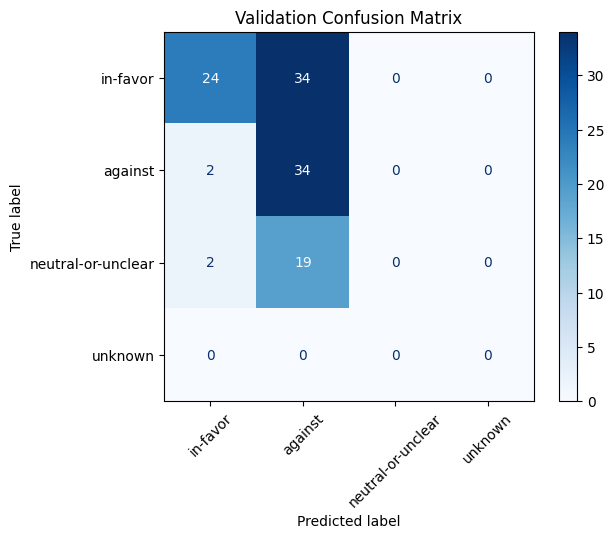

In [ ]:
# Accuracy
correct = sum([
    normalize(p) == normalize(l)
    for p, l in zip(preds, labels)
])
accuracy = correct / len(labels)
print(f"\nValidation Accuracy: {accuracy:.3f}")

# Optional: show simple class distribution and mismatches
from collections import Counter
print("\nPrediction counts:", Counter(preds))
print("Label counts:     ", Counter(labels))

# Optional: show confusion matrix
try:
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    cm = confusion_matrix(labels, preds, labels=["in-favor", "against", "neutral-or-unclear", "unknown"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["in-favor", "against", "neutral-or-unclear", "unknown"])
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Validation Confusion Matrix")
    plt.show()
except ImportError:
    print("Install `scikit-learn` and `matplotlib` for confusion matrix support.")


In [ ]:
wrong_df = pd.DataFrame(wrong)
wrong_df

,tweet,true_label,prev_pred
0,"people who won’t wear masks bc they say they have a “medical condition” that prevents them from wearing them, are the same folk who refuse to get the vaccine even though said “medical condition” would make them eligible &amp; put them at extra covid risk. in short, they’re just liars",in-favor,against
1,3 deaths have been linked to getting vaccinated and 4.23 million deaths have been linked to not getting vaccinated. it’s so hard to decide.,in-favor,against
2,601 of those were reported in america where 50million doses have been given meaning 0.001% of those vaccinated,in-favor,against
3,i’m wondering if the vaccination data collected will ever be reported...,neutral-or-unclear,against
4,"good. i’ll stop being a “non vaxxer” as soon as the drug companies waive their lawsuit immunity, and release all their safety test results. since their vaccines are so safe, that shouldn’t be a problem, right?",against,in-favor
5,covid vaccines do not cause infertility: health ministry #covidvaccine #infertility #fakenews,in-favor,against
6,cdc did not change the pcr for vaxxed people.,neutral-or-unclear,against
7,"dear tucker carlson. if you are successfully vaxxed and boosted to protect you against hospitalization or death from covid, why do you tell your viewers that the vaccine is bad?",in-favor,against
8,"y’all screaming “my body, my choice” about covid vaccines should realize that we’re spiraling into “my er, my choice” about who receives treatment.",in-favor,against
9,"cal/osha, the board that oversees workplace safety, is ordering all californians to remain masked at work until at least october, unless everyone around them is vaccinated. -",in-favor,against


In [ ]:
df["label_majority"].value_counts()

,count
label_majority,
in-favor,2907
against,1804
neutral-or-unclear,1040


In [ ]:
len(df)

5751